# Install dependencies

In [65]:
%pip install --upgrade pip
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install nltk
%pip install scikit-learn
%pip install joblib

import nltk

nltk.download('all')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated pa

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /home/vscode/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /home/vscode/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /home/vscode/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /home/vscode/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /home/vscode/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_dat

True

# Load dataset and initial checks

In [66]:
import pandas as pd

file = "../resources/dataset/youtoxic_english_1000.csv"

df = pd.read_csv(file)

display(df.columns)

print("--- Missing Value Counts ---")
print(df.isnull().sum())

print("\n--- Missing Value Percentages ---")
total_rows = len(df)
print((df.isnull().sum() / total_rows) * 100)

print("\n--- DataFrame Data Types ---")
print(df.dtypes)

exact_duplicates = df.duplicated().sum()
print(f"\nNumber of exact duplicates (all columns): {exact_duplicates}")

text_duplicates = df['Text'].duplicated().sum()
print(f"\nNumber of duplicate text entries: {text_duplicates}")

if text_duplicates > 0:
    duplicate_texts = df[df['Text'].duplicated(keep=False)].sort_values(by='Text').head(10)
    print("\nSample of rows with duplicated text:")
    print(duplicate_texts[['CommentId', 'Text', 'IsToxic']])

Index(['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat',
       'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist',
       'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate',
       'IsRadicalism'],
      dtype='object')

--- Missing Value Counts ---
CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64

--- Missing Value Percentages ---
CommentId          0.0
VideoId            0.0
Text               0.0
IsToxic            0.0
IsAbusive          0.0
IsThreat           0.0
IsProvocative      0.0
IsObscene          0.0
IsHatespeech       0.0
IsRacist           0.0
IsNationalist      0.0
IsSexist           0.0
IsHomophobic       0.0
IsReligiousHate    0.0
IsRadicalism       0.0
dtype: float64

--- DataFrame Data Types ---
CommentId          object
VideoId            object
Text               object
IsToxic              bool
IsAbusive            bool
IsThreat             bool
IsProvocative        bool
IsObscene            bool
IsHatespee

The initial data checks show that there are not null values in the dataset, no duplicates rows, and only a small set of repeated text. Since all off them seem to have a different comment ID, we can keep them. Let continue with outliers for the comments to try to identy too short or too long messages.


--- Word Count Descriptive Statistics ---
count    1000.000000
mean       33.776000
std        49.069498
min         1.000000
25%         9.000000
50%        19.000000
75%        39.000000
max       815.000000
Name: WordCount, dtype: float64


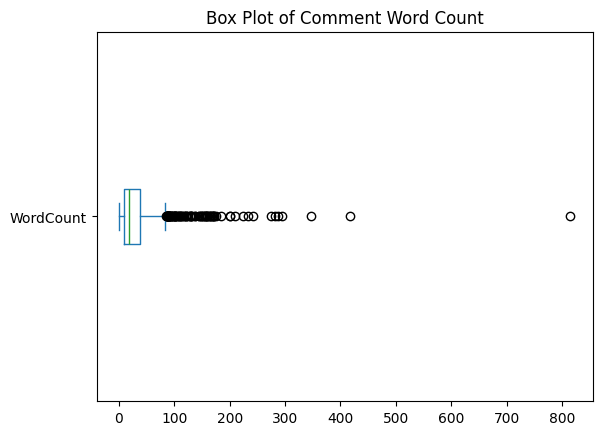


Number of extremely long comments (>500 words): 1


In [67]:
df['WordCount'] = df['Text'].apply(lambda x: len(str(x).split()))

print("\n--- Word Count Descriptive Statistics ---")
print(df['WordCount'].describe())

import matplotlib.pyplot as plt
df['WordCount'].plot(kind='box', vert=False)
plt.title('Box Plot of Comment Word Count')
plt.show()

long_comments = df[df['WordCount'] > 500]
print(f"\nNumber of extremely long comments (>500 words): {len(long_comments)}")

Shows that there are comments very short (just one word) and comments very long (more than 500 words). We should analyze those words to decide if they are actual comments or perhaps long-form articles/system logs/spam? If they are irrelevant, they can be removed or truncated, as they often skew tokenization/vectorization efforts.

Since there are only one short comment and one long comment, we can safely assume there are no outliers. If anything, they can be removed later.

# Univariate Analysis: Target distribution, ID counts.

### Label presence count

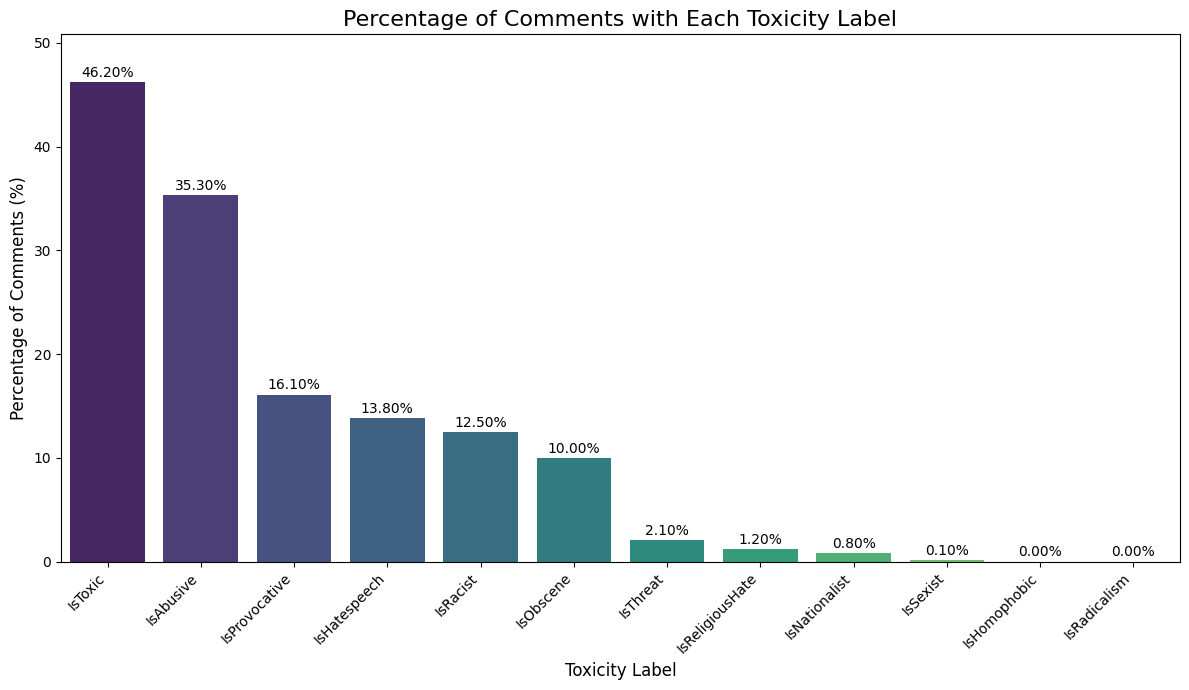

In [68]:
import seaborn as sns

label_cols = [col for col in df.columns if col.startswith('Is')]
label_counts = df[label_cols].sum().sort_values(ascending=False)

# print("--- Positive Label Counts ---")
# print(label_counts)

total_comments = len(df)
label_percentages = (label_counts / total_comments) * 100

# print("\n--- Positive Label Percentages ---")
# print(label_percentages)

plt.figure(figsize=(12, 7)) # Adjust figure size for better readability
sns.barplot(x=label_percentages.index, y=label_percentages.values, palette='viridis', hue=label_percentages.index)

# Add titles and labels
plt.title('Percentage of Comments with Each Toxicity Label', fontsize=16)
plt.xlabel('Toxicity Label', fontsize=12)
plt.ylabel('Percentage of Comments (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.ylim(0, max(label_percentages.values) * 1.1) # Add a small buffer to the y-axis limit

# Add the percentage values on top of the bars for clarity
for index, value in enumerate(label_percentages.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', color='black', ha='center')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


We can see there are two dominant labels: "IsToxic" and "IsAbusive". This points that there is a class imbalance. This can make the training of the model harder.

### Overall Non-Toxic vs. Toxic Comments

In [69]:
df['AnyToxic'] = df[label_cols].any(axis=1).astype(int)

toxic_count = df['AnyToxic'].sum()
non_toxic_count = total_comments - toxic_count
toxic_percentage = (toxic_count / total_comments) * 100

print(f"\nTotal Toxic Comments (at least one label): {toxic_count} ({toxic_percentage:.2f}%)")
print(f"Total Non-Toxic Comments (zero labels): {non_toxic_count} ({(100 - toxic_percentage):.2f}%)")


Total Toxic Comments (at least one label): 462 (46.20%)
Total Non-Toxic Comments (zero labels): 538 (53.80%)


It seems data is more or less balanced.

### Number of labels per comment

In [70]:
df['LabelCount'] = df[label_cols].sum(axis=1)

label_count_distribution = df['LabelCount'].value_counts().sort_index()

print("\n--- Distribution of Labels per Comment ---")
print(label_count_distribution)


--- Distribution of Labels per Comment ---
LabelCount
0    538
2    100
3    294
4     47
5     15
6      6
Name: count, dtype: int64


# Comparative Analysis: Text Length Analysis (Toxic vs. Non-Toxic).

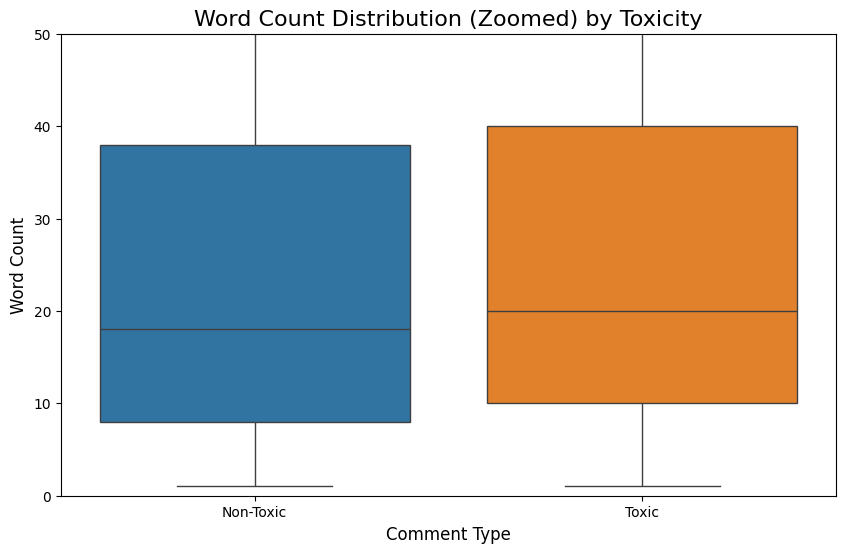

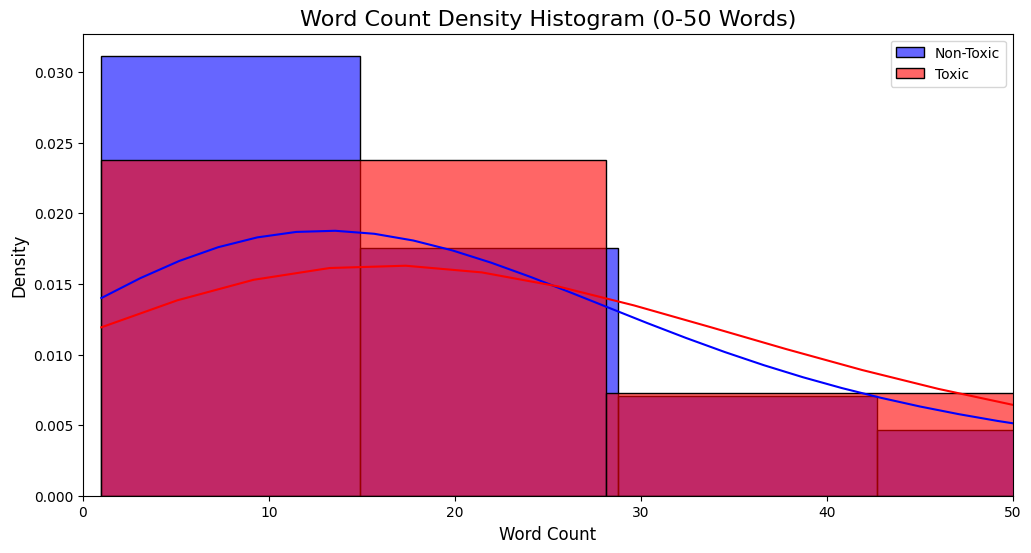

In [71]:
label_cols = [col for col in df.columns if col.startswith('Is')]

df['WordCount'] = df['Text'].apply(lambda x: len(str(x).split()))

df['AnyToxic'] = df[label_cols].any(axis=1).astype(int)

toxic_word_counts = df[df['AnyToxic'] == 1]['WordCount']
non_toxic_word_counts = df[df['AnyToxic'] == 0]['WordCount']

# print("--- Word Count Descriptive Statistics ---")
# print("\nToxic Comments:")
# print(toxic_word_counts.describe())

# print("\nNon-Toxic Comments:")
# print(non_toxic_word_counts.describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Melt the data for easier plotting with seaborn
word_count_data = df[['WordCount', 'AnyToxic']].copy()
word_count_data['Toxicity'] = word_count_data['AnyToxic'].apply(lambda x: 'Toxic' if x == 1 else 'Non-Toxic')

sns.boxplot(x='Toxicity', y='WordCount', data=word_count_data, palette=['#1f77b4', '#ff7f0e'], hue='Toxicity')

# Zooming in on the common range (e.g., words < 50) because of long outliers
plt.ylim(0, 50) 
plt.title('Word Count Distribution (Zoomed) by Toxicity', fontsize=16)
plt.ylabel('Word Count', fontsize=12)
plt.xlabel('Comment Type', fontsize=12)
plt.show()

plt.figure(figsize=(12, 6))

# Plot the distribution for non-toxic comments
sns.histplot(non_toxic_word_counts, bins=30, kde=True, color='blue', label='Non-Toxic', alpha=0.6, stat='density')

# Plot the distribution for toxic comments
sns.histplot(toxic_word_counts, bins=30, kde=True, color='red', label='Toxic', alpha=0.6, stat='density')

# Zoom in for comparison (e.g., capping at 50 words)
plt.xlim(0, 50)
plt.title('Word Count Density Histogram (0-50 Words)', fontsize=16)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

# Bivariate/Multivariate Analysis: Label Co-occurrence (Heatmap).

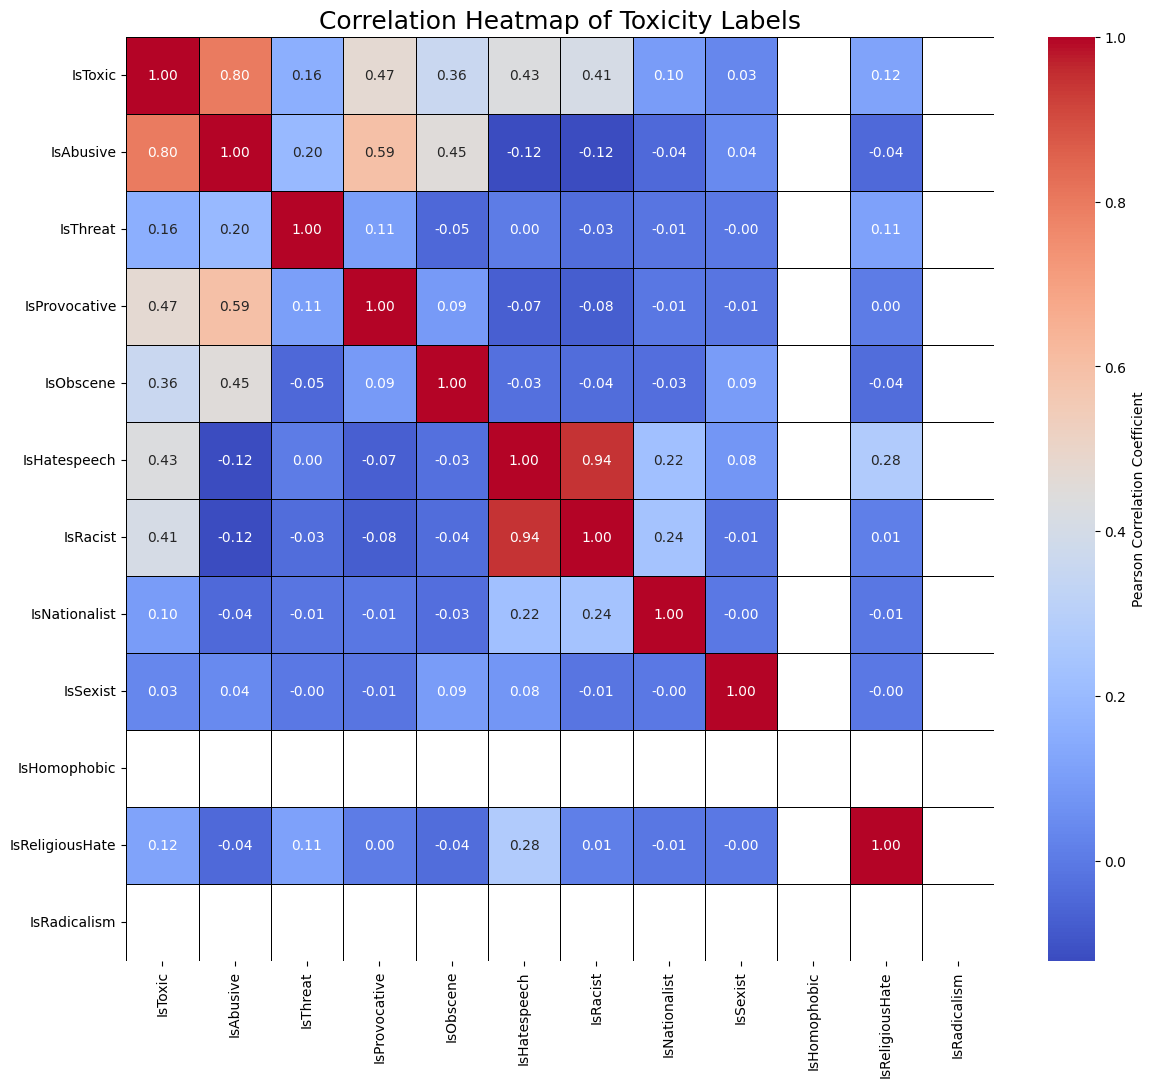

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with 0/1 integer labels
label_cols = [col for col in df.columns if col.startswith('Is')]

# Calculate the Pearson correlation matrix
correlation_matrix = df[label_cols].corr()

# Optional: Set the diagonal (self-correlation) to 0 or 1 for clarity
# correlation_matrix.values[[np.arange(correlation_matrix.shape[0])]*2] = 0

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,              # Annotate with the correlation value
    cmap='coolwarm',         # Colormap from cool (negative) to warm (positive)
    fmt=".2f",               # Format to two decimal places
    linewidths=.5,           # Add lines between cells
    linecolor='black',
    cbar_kws={'label': 'Pearson Correlation Coefficient'} # Color bar label
)
plt.title('Correlation Heatmap of Toxicity Labels', fontsize=18)
plt.show()

# Text-Specific Deep Dive: N-gram analysis, word clouds.

### N-gram analysis

In [73]:
from collections import Counter
import itertools
from nltk.corpus import stopwords
import re

# 1. Define Preprocessing Function (Simplified)
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return tokens

# 2. Analyze Global Frequencies (Unigrams)
all_tokens = df['Text'].apply(preprocess).explode()
global_unigram_counts = Counter(all_tokens).most_common(20)

print("--- Top 20 Global Unigrams (Entire Dataset) ---")
print(global_unigram_counts) # Example output: [('comment', 5200), ('video', 4800), ('like', 4100), ...]

# 3. Analyze Category-Specific Frequencies
tag='IsToxic'
bad_df = df[df[tag] == 1]
bad_tokens = bad_df['Text'].apply(preprocess).explode()
bad_unigram_counts = Counter(bad_tokens).most_common(20)

print(f"\n--- Top 20 Unigrams in '{tag}' Comments ---")
print(bad_unigram_counts)

tag='IsAbusive'
bad_df = df[df[tag] == 1]
bad_tokens = bad_df['Text'].apply(preprocess).explode()
bad_unigram_counts = Counter(bad_tokens).most_common(20)

print(f"\n--- Top 20 Unigrams in '{tag}' Comments ---")
print(bad_unigram_counts)

tag='IsProvocative'
bad_df = df[df[tag] == 1]
bad_tokens = bad_df['Text'].apply(preprocess).explode()
bad_unigram_counts = Counter(bad_tokens).most_common(20)

print(f"\n--- Top 20 Unigrams in '{tag}' Comments ---")
print(bad_unigram_counts)

--- Top 20 Global Unigrams (Entire Dataset) ---
[('people', 256), ('black', 246), ('police', 175), ('like', 151), ('get', 143), ('white', 135), ('would', 118), ('dont', 106), ('brown', 104), ('officer', 97), ('shot', 92), ('cop', 86), ('one', 82), ('video', 74), ('cops', 69), ('know', 67), ('man', 67), ('guy', 61), ('racist', 58), ('blacks', 57)]

--- Top 20 Unigrams in 'IsToxic' Comments ---
[('black', 130), ('people', 127), ('get', 79), ('white', 76), ('like', 75), ('police', 72), ('dont', 57), ('would', 57), ('brown', 50), ('fuck', 50), ('shot', 48), ('shit', 44), ('one', 39), ('officer', 38), ('cop', 37), ('man', 35), ('cops', 34), ('guy', 33), ('fucking', 33), ('blacks', 32)]

--- Top 20 Unigrams in 'IsAbusive' Comments ---
[('people', 76), ('black', 71), ('get', 61), ('police', 60), ('fuck', 47), ('dont', 41), ('shit', 39), ('like', 38), ('would', 37), ('brown', 34), ('shot', 34), ('fucking', 32), ('cop', 31), ('guy', 30), ('one', 29), ('white', 28), ('cops', 28), ('run', 26), ('

### Word clouds

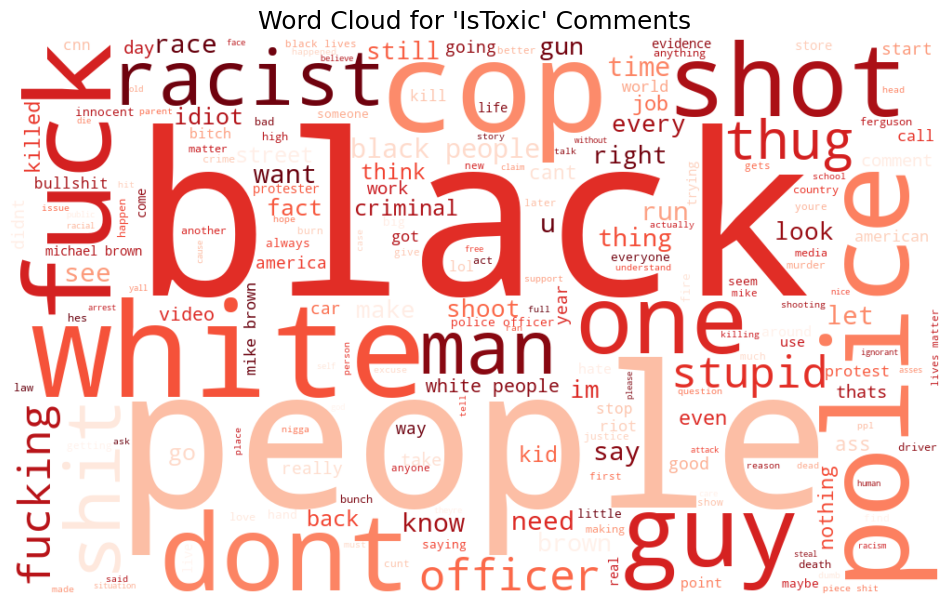

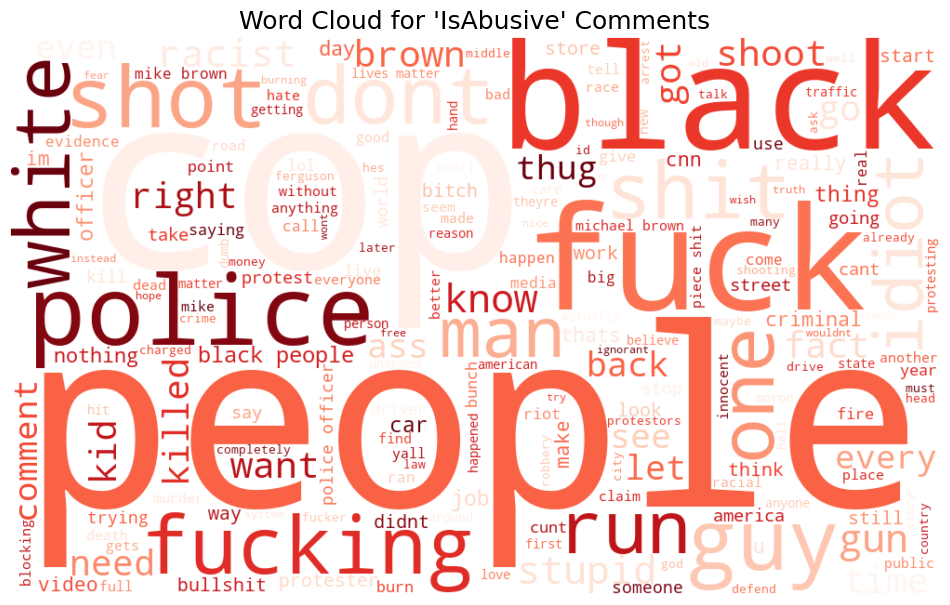

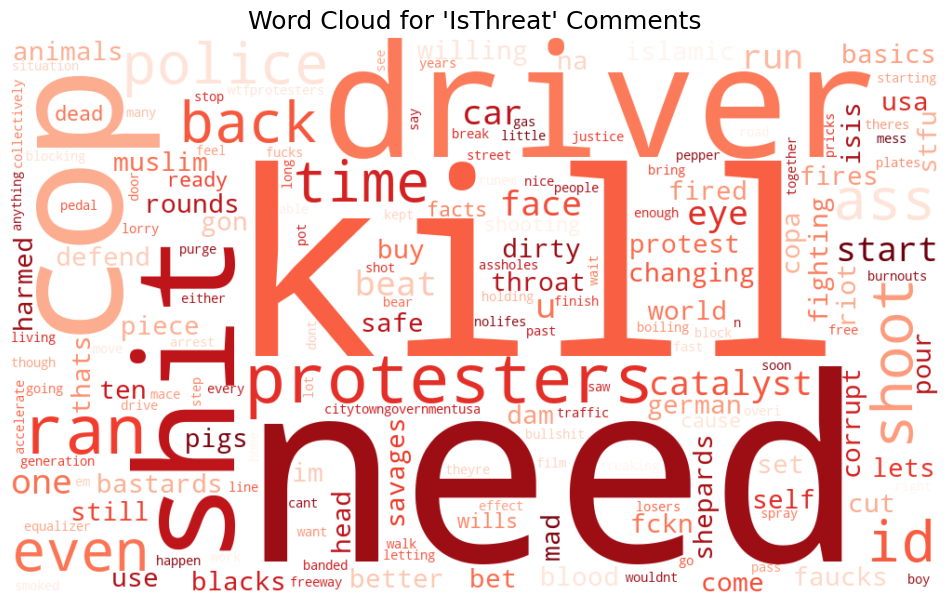

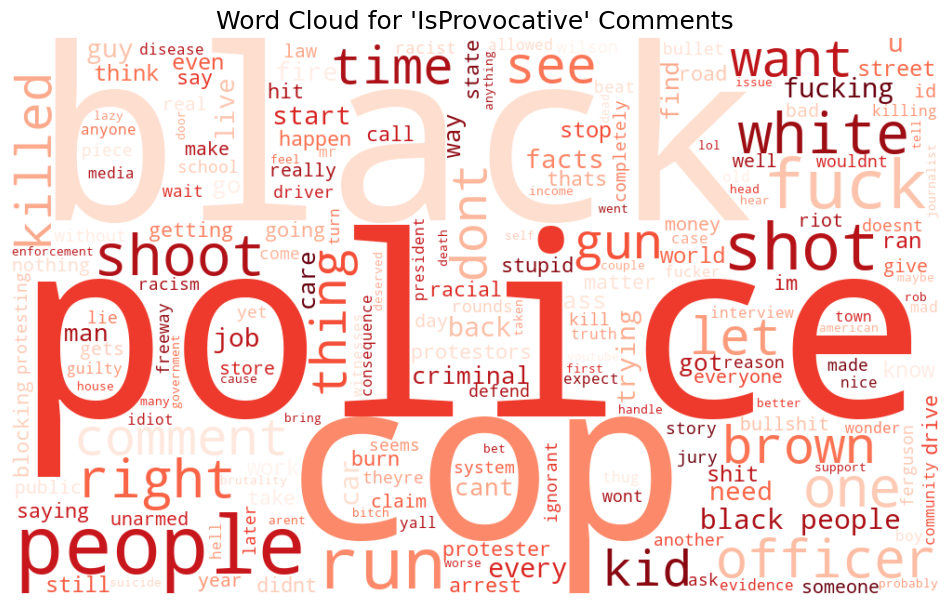

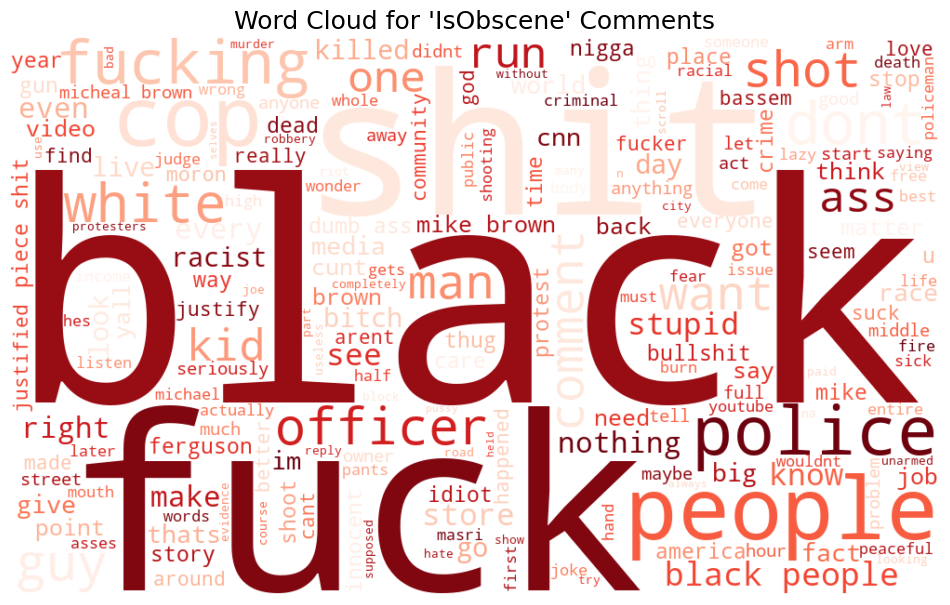

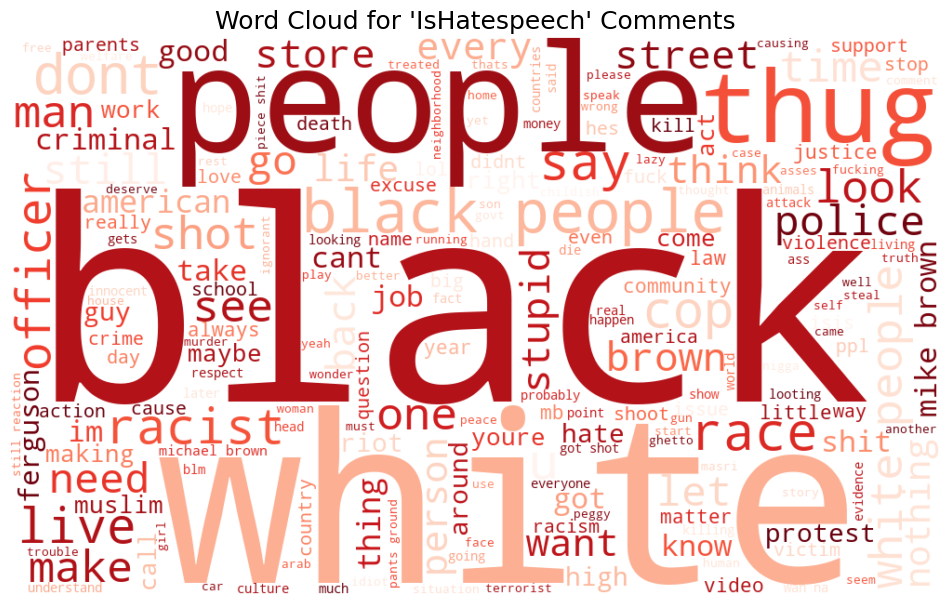

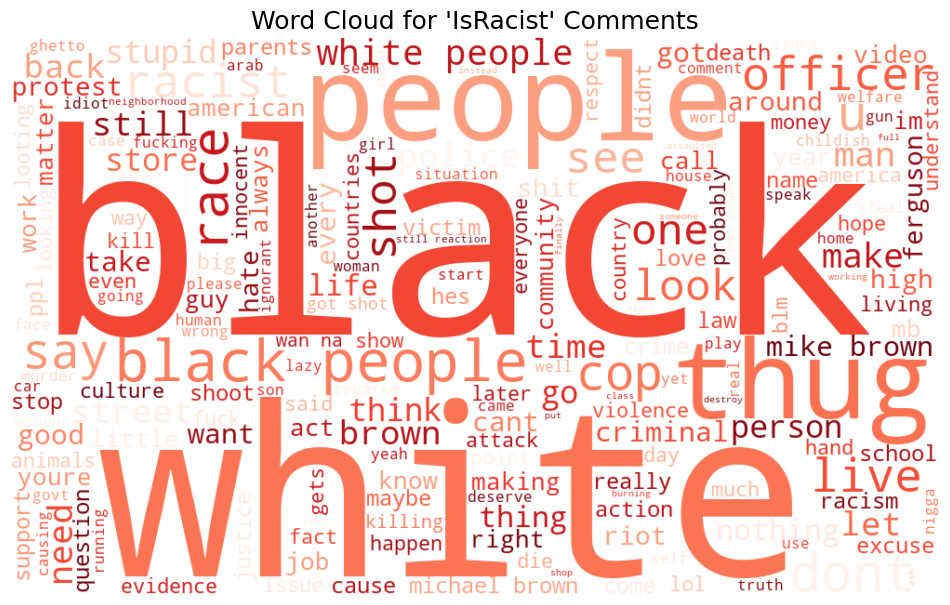

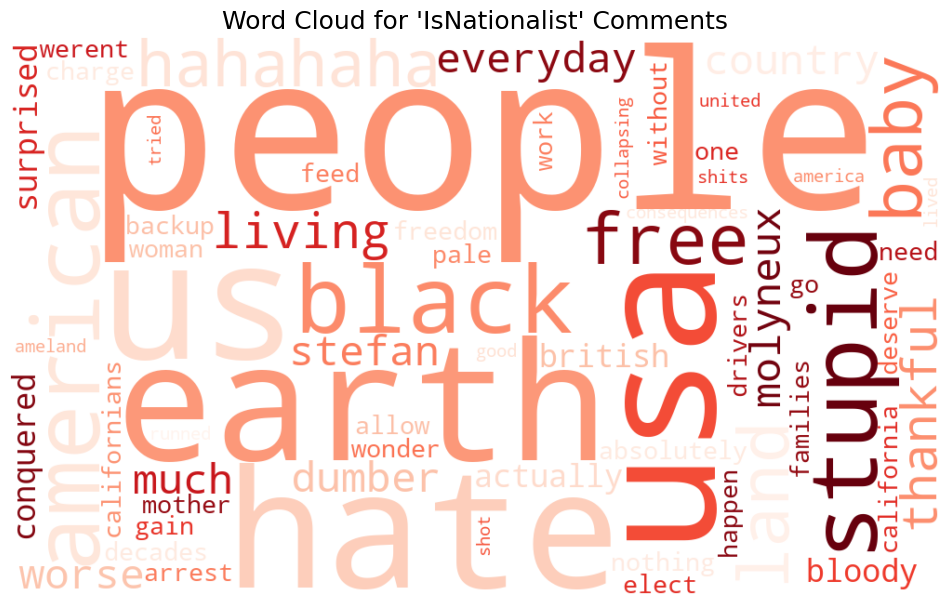

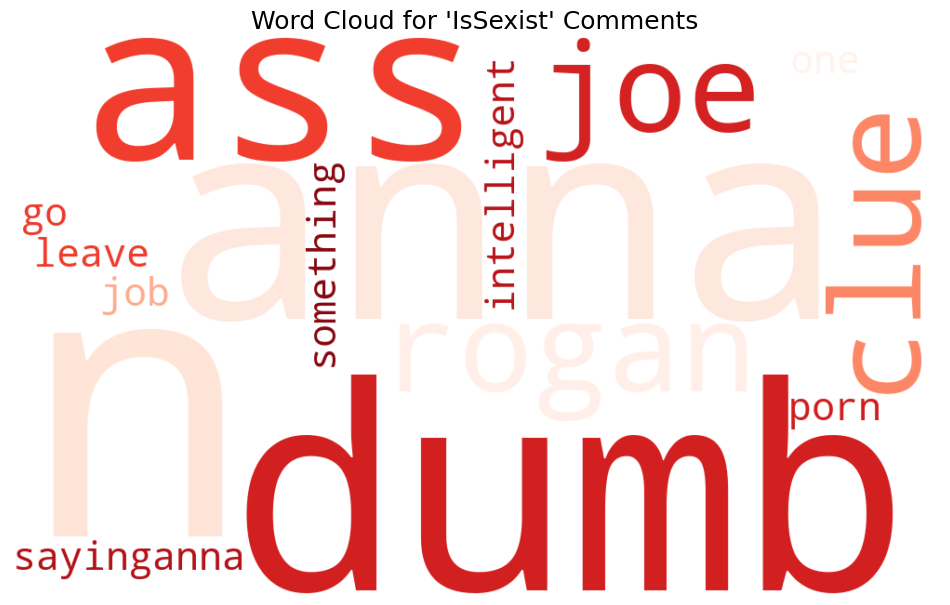

Topic IsHomophobic is too small.


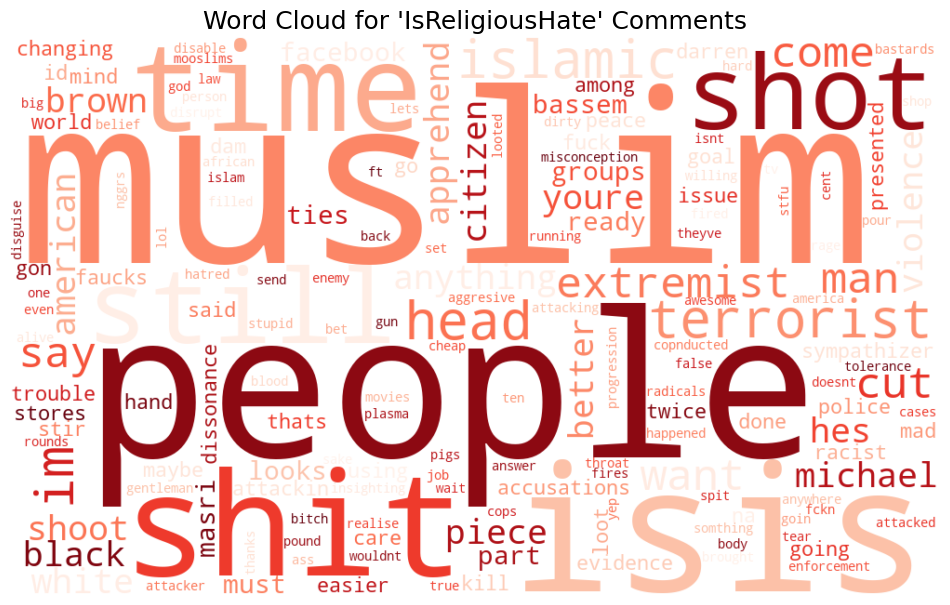

Topic IsRadicalism is too small.


In [74]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Cleans, normalizes, and tokenizes a single comment.
    """
    # 1. Ensure text is string and convert to lowercase
    text = str(text).lower()

    # 2. Remove URLs (common in comments)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove punctuation (optional, but good for n-gram counting)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Tokenize the text
    tokens = word_tokenize(text)

    # 5. Remove non-alphabetic tokens and stop words
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in STOP_WORDS]
    
    return tokens

def paint_cloud(tag):
    tag_df = df[df[tag] == 1].copy()
    if len(tag_df) > 0:
        tag_df['Tokens'] = tag_df['Text'].apply(preprocess_text)
        tokens = tag_df['Tokens'].explode().tolist()

        text_for_cloud = " ".join(tokens)
        # ----------------------------

        # Initialize the WordCloud object
        wordcloud = WordCloud(
            width=1000, 
            height=600, 
            background_color='white',
            # Optionally, you can pass a list of stop words here if you skipped them earlier
            # stopwords=set(stopwords.words('english')), 
            colormap='Reds' # A color palette suitable for the category
        ).generate(text_for_cloud)

        # Display the generated image:
        plt.figure(figsize=(12, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off") # Hide the axes
        plt.title(f"Word Cloud for '{tag}' Comments", fontsize=18)
        plt.show()
    else:
        print(f"Topic {tag} is too small.")
    
for item in [col for col in df.columns if col.startswith('Is')]:
    paint_cloud(item)

# Train a ML model using traditional ML models: SVM, Logistic regression and Naïve Bayes

### Logistic regression

We start by cleaning the text column

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier # Crucial for multi-label
from sklearn.metrics import classification_report
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization (reducing words to their base or root form)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join tokens back into a single string
    return ' '.join(tokens)

df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

print("\n--- Cleaned Data Sample ---")
print(df[['Text', 'Cleaned_Text']].head())


--- Cleaned Data Sample ---
                                                Text  \
0  If only people would just take a step back and...   
1  Law enforcement is not trained to shoot to app...   
2  \nDont you reckon them 'black lives matter' ba...   
3  There are a very large number of people who do...   
4  The Arab dude is absolutely right, he should h...   

                                        Cleaned_Text  
0  people would take step back make case wasnt an...  
1  law enforcement trained shoot apprehend traine...  
2  dont reckon black life matter banner held whit...  
3  large number people like police officer called...  
4  arab dude absolutely right shot extra time sho...  


Continue with text vectorization and training of the model using logistic regression.

In [76]:
X = df['Cleaned_Text']

# Remove IsThreat, isReligiousHate, Is Nationalist, IsSexist, IsHomophobic and isRadicalism
# as the count is too low and will not add vaue to the model.
target_cols = [
    'IsToxic', 
    'IsAbusive', 
    'IsProvocative', 
    'IsObscene', 
    'IsHatespeech', 
    'IsRacist',
    'IsThreat',
    'IsReligiousHate',
    'IsNationalist',
    # 'IsSexist'
]
y = df[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and Fit TF-IDF Vectorizer. We specify the analyzer for characters and
# ngram in a range of 4 to 5 words
tfidf_vectorizer = TfidfVectorizer(max_features=5000, analyzer='char', ngram_range=(3, 5))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"Training Target Shape: {y_train.shape}")

base_lr = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Wrap the base classifier for multi-label classification
# This creates a separate LR model for each of the 12 columns in y
multi_target_classifier = MultiOutputClassifier(base_lr, n_jobs=-1)

# Train the model
print("\n--- Training Multi-Label Model (12 classifiers) ---")
multi_target_classifier.fit(X_train_tfidf, y_train)
print("Model training complete.")


TF-IDF Matrix Shape (Train): (800, 5000)
Training Target Shape: (800, 9)

--- Training Multi-Label Model (12 classifiers) ---
Model training complete.


Eavluation of the trained model

In [77]:
# Make predictions on the test set
# The output is a matrix of predictions (rows, 12 columns)
y_pred = multi_target_classifier.predict(X_test_tfidf)

print("\n--- Model Evaluation (Multi-Label) ---")

# Evaluate performance for each label separately
print("Classification Report for all 12 labels:")
# We use the classification report on the full matrix
# The `target_names` parameter labels the columns correctly
print(classification_report(y_test, y_pred, target_names=target_cols, zero_division=0))

# Micro-Averaged F1-Score (A common metric for multi-label problems)
from sklearn.metrics import f1_score
micro_f1 = f1_score(y_test, y_pred, average='micro')

print(f"\nMicro-Averaged F1-Score (Overall performance across all labels): {micro_f1:.4f}")


--- Model Evaluation (Multi-Label) ---
Classification Report for all 12 labels:
                 precision    recall  f1-score   support

        IsToxic       0.73      0.67      0.70       107
      IsAbusive       0.70      0.74      0.72        77
  IsProvocative       0.42      0.39      0.41        38
      IsObscene       0.44      0.48      0.46        23
   IsHatespeech       0.61      0.63      0.62        35
       IsRacist       0.65      0.67      0.66        30
       IsThreat       0.00      0.00      0.00         4
IsReligiousHate       0.00      0.00      0.00         4
  IsNationalist       0.00      0.00      0.00         3

      micro avg       0.63      0.61      0.62       321
      macro avg       0.39      0.40      0.40       321
   weighted avg       0.62      0.61      0.62       321
    samples avg       0.36      0.33      0.33       321


Micro-Averaged F1-Score (Overall performance across all labels): 0.6205


Let's optimize the model...

In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score

# Define the performance metric scorer
# We use 'micro' F1-score because it's the standard metric for overall multi-label performance.
micro_f1_scorer = make_scorer(f1_score, average='micro')

# Define the parameter grid to search
param_grid = {
    # The 'estimator__C' targets the C parameter of the base LogisticRegression estimator
    'estimator__C': [0.1, 1, 10], 
    # Optional: Test different regularization penalties (L1 for feature selection, L2 for general)
    'estimator__penalty': ['l1', 'l2'] 
}

# Define the base model (using 'liblinear' solver for simplicity)
base_lr = LogisticRegression(
    solver='liblinear',
    random_state=42,
    # Crucial for stability in imbalanced data:
    class_weight='balanced', 
    max_iter=50000 
)
moc = MultiOutputClassifier(base_lr, n_jobs=-1)

# Initialize GridSearchCV
# cv=3 means 3-fold cross-validation
# n_jobs=-1 uses all available processors
print("Starting GridSearchCV for optimal C parameter...")

grid_search = GridSearchCV(
    estimator=moc,
    param_grid=param_grid,
    scoring=micro_f1_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit the grid search to your training data (X_train_tfidf, y_train)
# Note: Ensure X_train_tfidf and y_train are available from your previous steps
grid_search.fit(X_train_tfidf, y_train)

print(f"\nBest Micro F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters found: {grid_search.best_params_}")

Starting GridSearchCV for optimal C parameter...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Micro F1 Score: 0.5346
Best Parameters found: {'estimator__C': 1, 'estimator__penalty': 'l2'}


... and show the results.

In [79]:
import joblib


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tfidf_vectorizer_final = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 3) # Using (1, 3) N-grams as an optimization
)

X_train_tfidf = tfidf_vectorizer_final.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer_final.transform(X_test)

base_lr_final = LogisticRegression(
    C=grid_search.best_params_['estimator__C'],
    penalty=grid_search.best_params_['estimator__penalty'],
    solver='liblinear',        # Using liblinear/saga (adjust based on your best solver)
    random_state=42,
    max_iter=50000,
    class_weight='balanced'    # Recommended to keep this for imbalance compensation
)

# Wrap and train the MultiOutputClassifier
final_model = MultiOutputClassifier(base_lr_final, n_jobs=-1)

# Fit the model to the optimized TF-IDF features
final_model.fit(X_train_tfidf, y_train)

print("Final model training complete.")

y_pred_final = final_model.predict(X_test_tfidf)

# Evaluate performance
print("\n--- Final Model Evaluation ---")

# Classification Report
# zero_division=0 prevents the UndefinedMetricWarning for any remaining rare labels
report = classification_report(
    y_test, 
    y_pred_final, 
    target_names=target_cols, 
    zero_division=0
)
print("Classification Report:")
print(report)

# Micro-Averaged F1-Score
micro_f1 = f1_score(y_test, y_pred_final, average='micro')
print(f"\nMicro-Averaged F1-Score (Overall Performance): {micro_f1:.4f}")

# Save model and vectorizer
joblib.dump(final_model, '../resources/models/logistic_regression.pkl')
joblib.dump(tfidf_vectorizer_final, '../resources/models/text_vectorizer.pkl')


Final model training complete.

--- Final Model Evaluation ---
Classification Report:
                 precision    recall  f1-score   support

        IsToxic       0.78      0.67      0.72       157
      IsAbusive       0.71      0.62      0.66       113
  IsProvocative       0.50      0.32      0.39        53
      IsObscene       0.39      0.38      0.39        34
   IsHatespeech       0.54      0.49      0.51        55
       IsRacist       0.53      0.49      0.51        49
       IsThreat       0.00      0.00      0.00         8
IsReligiousHate       0.50      0.20      0.29         5
  IsNationalist       0.33      0.25      0.29         4

      micro avg       0.64      0.54      0.59       478
      macro avg       0.48      0.38      0.42       478
   weighted avg       0.63      0.54      0.58       478
    samples avg       0.33      0.29      0.30       478


Micro-Averaged F1-Score (Overall Performance): 0.5864


['../resources/models/text_vectorizer.pkl']

### Naïve Bayes ML

In [80]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the TF-IDF Vectorizer (using N-grams for optimization)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 3) # Using your optimized N-grams
)

# Fit and Transform the data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\n--- Training Multinomial Naive Bayes Model ---")

# Define the base classifier (Multinomial Naive Bayes)
# alpha (smoothing parameter) is set to 1.0 (Laplace smoothing) by default, 
# which prevents zero probabilities and is good practice.
base_mnb = ComplementNB(alpha=1)

# Wrap the base classifier for multi-label classification
# This trains a separate MNB model for each of the target columns.
multi_target_mnb = MultiOutputClassifier(base_mnb, n_jobs=-1)

# Train the model
multi_target_mnb.fit(X_train_tfidf, y_train)

print("Model training complete.")

# Make predictions on the test set
y_pred_mnb = multi_target_mnb.predict(X_test_tfidf)

print("\n--- MNB Model Evaluation ---")

# Classification Report
# zero_division=0 prevents warnings for un-predicted rare labels
report = classification_report(
    y_test, 
    y_pred_mnb, 
    target_names=target_cols, 
    zero_division=0
)
print("Classification Report:")
print(report)

# Micro-Averaged F1-Score
micro_f1 = f1_score(y_test, y_pred_mnb, average='micro')
print(f"\nMicro-Averaged F1-Score (Overall Performance): {micro_f1:.4f}")

#######################################

from sklearn.model_selection import GridSearchCV

# Define the performance metric scorer (using the micro F1-score)
micro_f1_scorer = make_scorer(f1_score, average='micro', zero_division=0)

# Parameter grid for alpha tuning
param_grid_mnb = {
    'estimator__alpha': [1.0, 0.5, 0.1, 0.01] 
}

# Define the base model
base_mnb = ComplementNB()
multi_target_mnb = MultiOutputClassifier(base_mnb, n_jobs=-1)

# Run Grid Search
mnb_grid_search = GridSearchCV(
    estimator=multi_target_mnb,
    param_grid=param_grid_mnb,
    scoring=micro_f1_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

mnb_grid_search.fit(X_train_tfidf, y_train) 
print(f"Best MNB Alpha: {mnb_grid_search.best_params_}")

base_mnb = ComplementNB(alpha=mnb_grid_search.best_params_['estimator__alpha'])

# Wrap the base classifier for multi-label classification
# This trains a separate MNB model for each of the target columns.
final_model = MultiOutputClassifier(base_mnb, n_jobs=-1)
final_model.fit(X_train_tfidf, y_train)

# Save model and vectorizer
joblib.dump(final_model, '../resources/models/naive_bayes.pkl')


--- Training Multinomial Naive Bayes Model ---
Model training complete.

--- MNB Model Evaluation ---
Classification Report:
                 precision    recall  f1-score   support

        IsToxic       0.78      0.65      0.71       107
      IsAbusive       0.83      0.58      0.69        77
  IsProvocative       0.71      0.13      0.22        38
      IsObscene       0.50      0.17      0.26        23
   IsHatespeech       0.33      0.03      0.05        35
       IsRacist       0.00      0.00      0.00        30
       IsThreat       0.00      0.00      0.00         4
IsReligiousHate       0.00      0.00      0.00         4
  IsNationalist       0.00      0.00      0.00         3

      micro avg       0.75      0.39      0.51       321
      macro avg       0.35      0.17      0.21       321
   weighted avg       0.62      0.39      0.45       321
    samples avg       0.35      0.22      0.25       321


Micro-Averaged F1-Score (Overall Performance): 0.5123
Fitting 3 folds fo

['../resources/models/naive_bayes.pkl']